# Case Study 48: High-Dimensional Data Analysis Using PCA and Clustering
Dataset: Wine (13 chemical features, 178 samples)

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Load the dataset
We keep the true labels (`y`) only to check our clusters at the end. They are NOT used for clustering.

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Shape:", X.shape)
X.head()

Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploratory Data Analysis

In [3]:
print("Missing values:", X.isnull().sum().sum())
X.describe()

Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


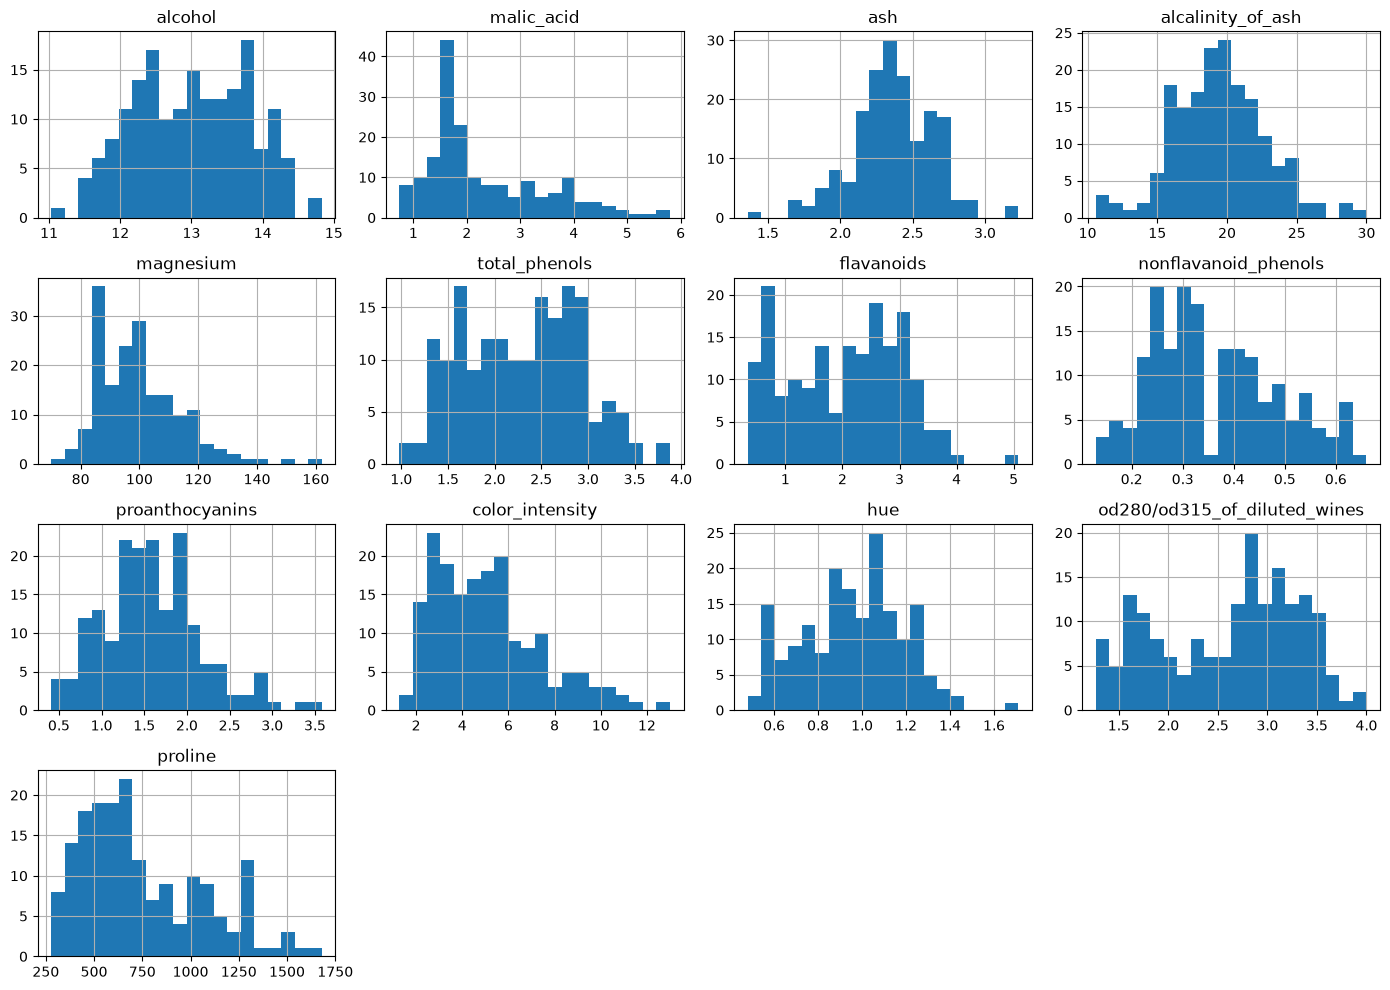

In [4]:
X.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

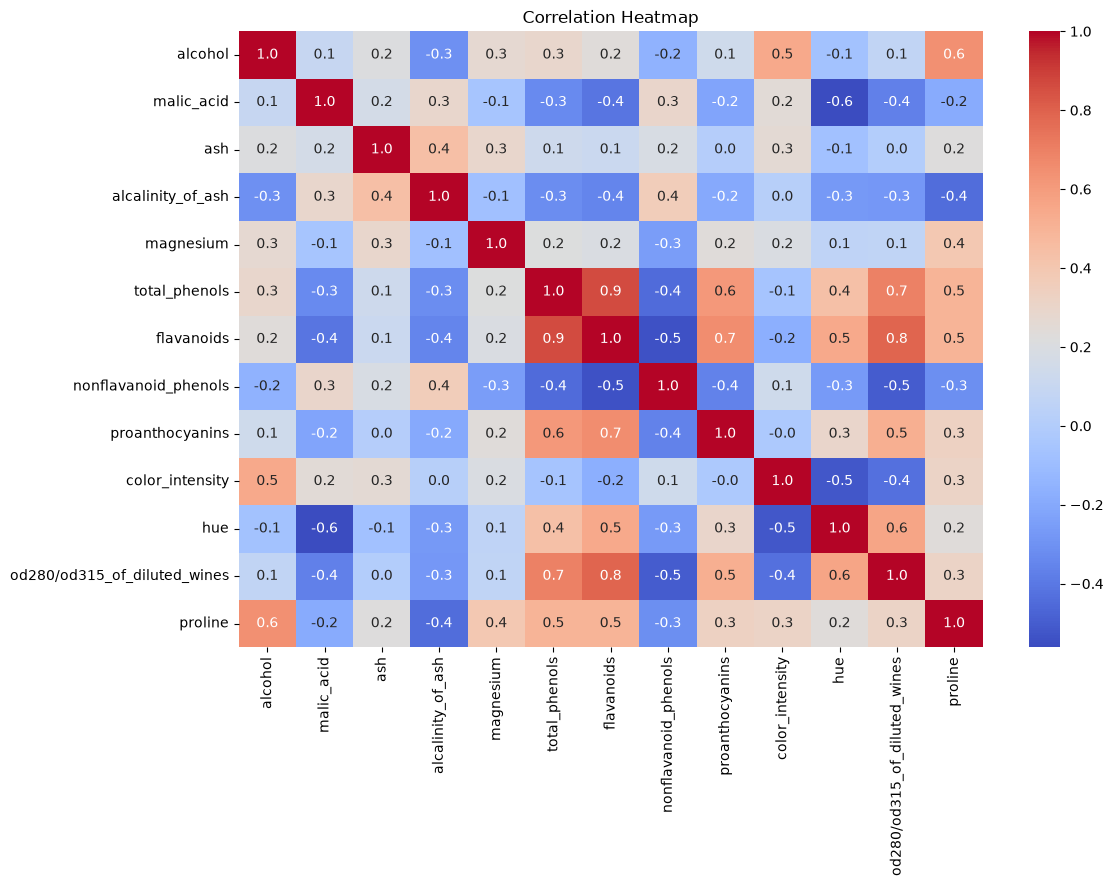

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 4. Feature scaling (mandatory before PCA)
PCA looks for the direction with the most variance. Features with big numbers (like proline) would dominate, so we scale everything to mean 0 and std 1.

In [6]:
print("Std BEFORE scaling:")
print(X[["proline", "hue"]].std())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStd AFTER scaling:", X_scaled.std(axis=0).round(2)[:3], "...")

Std BEFORE scaling:
proline    314.907474
hue          0.228572
dtype: float64

Std AFTER scaling: [1. 1. 1.] ...


## 5. PCA and cumulative explained variance

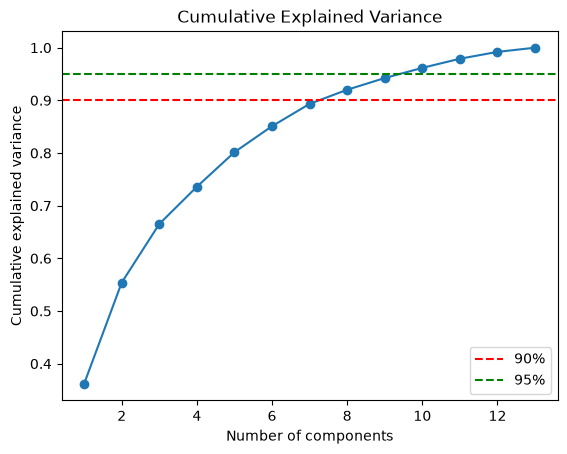

Components for 90% variance: 8
Components for 95% variance: 10
Variance kept by first 2 components: 0.554


In [7]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, 14), cum_var, marker="o")
plt.axhline(0.90, color="r", linestyle="--", label="90%")
plt.axhline(0.95, color="g", linestyle="--", label="95%")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

print("Components for 90% variance:", np.argmax(cum_var >= 0.90) + 1)
print("Components for 95% variance:", np.argmax(cum_var >= 0.95) + 1)
print("Variance kept by first 2 components:", round(cum_var[1], 3))

## 6. Reduce to 2 dimensions

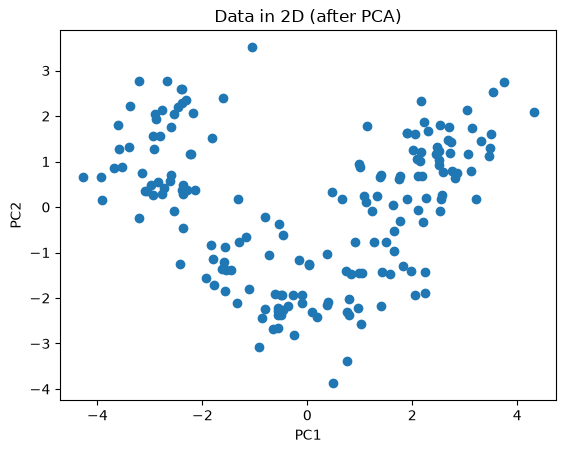

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data in 2D (after PCA)")
plt.show()

## 7. Elbow method (WCSS) to find the best K

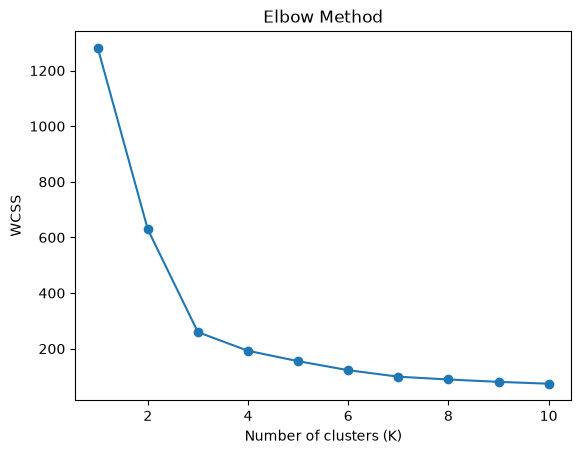

In [9]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 8. K-Means clustering (K = 3) on PCA data

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_pca)

print("Cluster sizes:", np.bincount(labels_km))

Cluster sizes: [64 49 65]


## 9. Hierarchical clustering and dendrogram

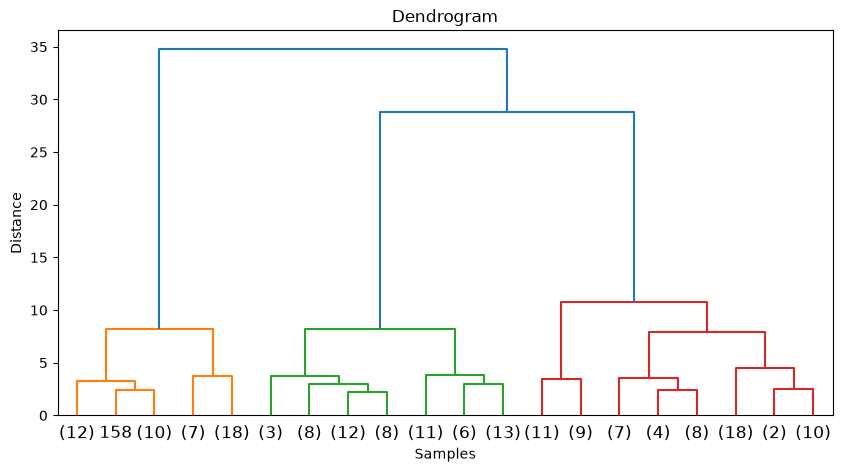

In [11]:
Z = linkage(X_pca, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [12]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_pca)

print("Cluster sizes:", np.bincount(labels_hc))

Cluster sizes: [69 48 61]


## 10. Visualise both clustering results

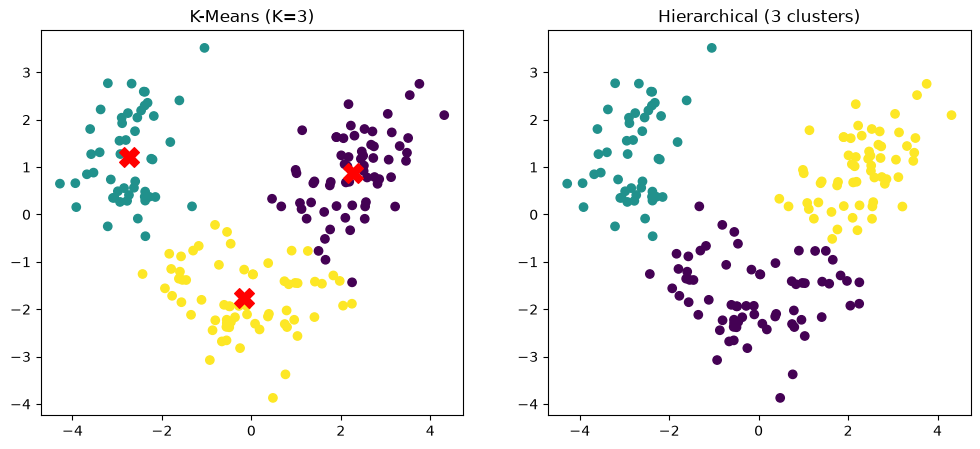

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="viridis")
ax[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
              c="red", marker="X", s=200)
ax[0].set_title("K-Means (K=3)")

ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, cmap="viridis")
ax[1].set_title("Hierarchical (3 clusters)")

plt.show()

## 11. Compare: clustering on original data vs PCA data

In [14]:
# K-Means on original (scaled) 13 features
km_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = km_orig.fit_predict(X_scaled)

results = pd.DataFrame({
    "Data": ["Original (13 features)", "PCA (2 components)"],
    "WCSS": [km_orig.inertia_, kmeans.inertia_],
    "Silhouette": [silhouette_score(X_scaled, labels_orig),
                   silhouette_score(X_pca, labels_km)],
    "ARI vs true labels": [adjusted_rand_score(y, labels_orig),
                           adjusted_rand_score(y, labels_km)],
    "Cluster sizes": [str(np.bincount(labels_orig)), str(np.bincount(labels_km))]
})
results

,Data,WCSS,Silhouette,ARI vs true labels,Cluster sizes
0,Original (13 features),1277.928489,0.284859,0.897495,[65 51 62]
1,PCA (2 components),259.509381,0.561051,0.895058,[64 49 65]


In [15]:
print("Hierarchical silhouette (PCA):", round(silhouette_score(X_pca, labels_hc), 3))
print("Hierarchical ARI (PCA):", round(adjusted_rand_score(y, labels_hc), 3))
print("K-Means silhouette (PCA):", round(silhouette_score(X_pca, labels_km), 3))
print("K-Means ARI (PCA):", round(adjusted_rand_score(y, labels_km), 3))

Hierarchical silhouette (PCA): 0.559
Hierarchical ARI (PCA): 0.896
K-Means silhouette (PCA): 0.561
K-Means ARI (PCA): 0.895


## 12. Save the models for Streamlit

In [16]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(kmeans, "kmeans.pkl")
joblib.dump((X_pca, labels_km), "pca_data.pkl")

print("Saved: scaler.pkl, pca.pkl, kmeans.pkl, pca_data.pkl")

Saved: scaler.pkl, pca.pkl, kmeans.pkl, pca_data.pkl


## 13. Final Analysis (fill the numbers from your outputs)

- **Components to keep most variance:** about 8 components keep 90%, about 10 keep 95%. The first 2 keep about 55%.
- **Number of distinct groups:** 3 (the elbow curve and the dendrogram both point to 3).
- **Before vs after PCA:** results are very similar. Compare the silhouette scores in the table above. PCA removes noise, so clusters look cleaner in 2D.
- **Why scaling is mandatory:** PCA maximises variance. Features with large values (proline) would dominate and the other features would be ignored. Scaling gives every feature equal importance.
- **Interpretability lost:** each principal component is a mix of all 13 original features, so PC1 and PC2 have no direct chemical meaning.
- **Cluster quality:** measured with WCSS, silhouette score and visual separation in 2D.
- **Lab classification:** the analysis can help group new samples, but the groups are unlabeled and the dataset is small (178 samples), so results need validation.
- **Limitations:** PCA is linear, K-Means needs K in advance, and 2 components lose about 45% of the information.